In [127]:
import math
import cv2
import numpy as np
from time import time
import imutils

import matplotlib.pyplot as plt

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [128]:
def draw_keypoints(frame, result, confidence_threshold):
    x, y, c = frame.shape
    #shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))
    points = []
    landmarks = result.pose_landmarks
    if landmarks:
        for pose in landmarks[0]: 
            points.append([pose.y, pose.x, pose.visibility])
        points = np.multiply(points, [x, y, 1])
        wanted = [0, 19, 20, 11, 12, 24, 23, 25, 26, 28, 27, 13, 14]
        smallPoints = []
        for want in wanted:
            smallPoints.append(points[want])
        for kp in smallPoints:
            ky, kx, kp_conf = kp
            if kp_conf > confidence_threshold:
                cv2.circle(frame, (int(kx), int(ky)), 4, (0, 255, 0), -1)

In [134]:

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Create a pose landmarker instance with the video mode:
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="../models/pose_landmarker_heavy.task"),
    running_mode=VisionRunningMode.VIDEO)

with PoseLandmarker.create_from_options(options) as landmarker:
  # The landmarker is initialized. Use it here.
  # ...
    videoPath = '../Data/flipturn.mp4'
    video = cv2.VideoCapture(videoPath)

    
    k = 0

    while video.isOpened():
        ret, frame = video.read()
        frame = imutils.resize(frame, width=800)
        if not ret:
            video.set(cv2.CAP_PROP_POS_FRAMES, 0)
            continue

        #frame = cv2.flip(frame, 1)

        frame_height, frame_width, _ = frame.shape

        #frame = cv2.resize(frame, (int(frame_width * (640 / frame_height)), 640))

        
        image = frame.copy()
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        pose_landmarker_result = landmarker.detect_for_video(mp_image, k)
        print(pose_landmarker_result)

        k = k+1
        draw_keypoints(frame, pose_landmarker_result, 0.4)
        cv2.imshow('Pose Detection', frame)
        if cv2.waitKey(10) & 0xFF==ord('q'):
            break

    video.release()
    cv2.destroyAllWindows()



    

PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.6440937519073486, y=0.6166417598724365, z=-0.10042084008455276, visibility=0.9990355968475342, presence=0.9993703961372375, name=

In [ ]:
x =pose_landmarker_result.pose_landmarks[0][14].x * 1920
y =pose_landmarker_result.pose_landmarks[0][14].y * 1080
# pose_landmarker_result.pose_landmarks[0][14].


cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
plt.imshow(frame, )

SyntaxError: invalid syntax (3304553363.py, line 3)

In [ ]:


# def detectPose(image, pose, display=True):
#     output_image = image.copy()

#     imageRGB = cv2.cvtColor(cv2.COLOR_BGR2RGB)
#     results = pose.process(imageRGB)

#     height, width, _ = image.shape
#     landmarks = []

#     if results.pose_landmarks:
#         mp_drawing.draw_landmarks(image=output_image, landmark_list=results.pose_landmarks, connection=mp.pose.POSE_CONNECTIONS)
#         for landmark in results.pose_landmarks.landmark:
#             landmarks.append((int(landmark.x * width), int(landmark.y * height), (landmark.z * width)))

#         if display:
#             plt.figure(fisize=[22,22])
#             plt.subplot(121);plt.imshow(image[:,:,:,1]);plt.title("Original image");plt.axis("off");
#             plt.subplot(122);plt.imshow(output_image[:,:,:,1]);plt.title("Output image");plt.axis("off");

#             mp_drawing.plot_landmarks(results.pose_world_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS))

#         else:
#             return output_image, landmarks


In [ ]:



#pose_video = mp_pose.Pose(static_image_mode =False, min_detection_confidence=0.3, model_complexity=1)


PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)
PoseLandma

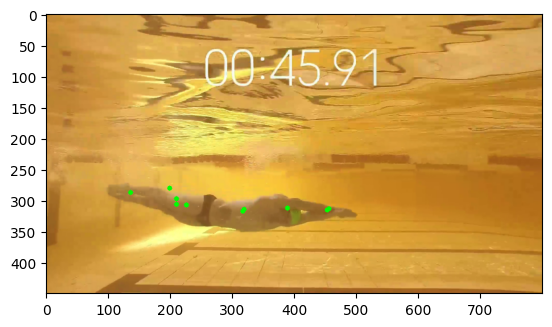

In [135]:
plt.imshow(frame)